# Regression with Real Data from OpenML

## This notebook will cover several different types of regression and show you how they can be used to analyze real data.

This notebook will cover the following models:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Elastic net regression
6. XGBoost
7. SVR
8. kNN
9. Decision Trees
10. SGD Regressor

## Before you get started, remember:

#### **MAE (Mean Absolute Error)**: Indicator of how far off your predictions are on average
#### **RMSE (Root Mean Squared Error)**: Similar to MAE, but punishes large errors much more than MAE
#### **R<sup>2</sup>**: Indicates how well your model predicts the target variable compared to simply guessing the mean

## 0) Setup & Imports

In [62]:
# ------------------------------------------------------------
# Core scientific computing libraries
# ------------------------------------------------------------
import numpy as np              # Numerical operations, arrays, linear algebra
import pandas as pd            # DataFrames, CSV loading, data manipulation
import matplotlib.pyplot as plt # Plotting (line charts, scatter plots, etc.)

# ------------------------------------------------------------
# Dataset loading and train/test splitting
# ------------------------------------------------------------
from sklearn.datasets import fetch_openml       # Loading datasets from OpenML
from sklearn.model_selection import train_test_split  # Splitting into train/test sets

# ------------------------------------------------------------
# Preprocessing and Pipelines
# ------------------------------------------------------------
from sklearn.preprocessing import (
    StandardScaler,            # Feature scaling (mean 0, std 1)
    PolynomialFeatures         # Expands X into polynomial terms for poly regression
)
from sklearn.pipeline import Pipeline           # Chains steps together cleanly

# ------------------------------------------------------------
# Linear-model family
# ------------------------------------------------------------
from sklearn.linear_model import (
    LinearRegression,  # Standard OLS linear regression
    Ridge,             # L2-regularized linear regression
    Lasso,             # L1-regularized linear regression
    ElasticNet,        # Combination of L1 + L2 regularization
    SGDRegressor       # Linear model optimized with stochastic gradient descent
)

# ------------------------------------------------------------
# Nonlinear models
# ------------------------------------------------------------
from sklearn.neighbors import KNeighborsRegressor   # KNN regression model
from sklearn.svm import SVR                         # Support Vector Regression
from sklearn.tree import DecisionTreeRegressor      # Decision Tree regressor

# ------------------------------------------------------------
# Model evaluation metrics
# ------------------------------------------------------------
from sklearn.metrics import (
    mean_squared_error,   # For RMSE calculation
    mean_absolute_error,  # MAE
    r2_score              # R² (coefficient of determination)
)

# ------------------------------------------------------------
# Gradient-boosted trees
# ------------------------------------------------------------
from xgboost import XGBRegressor  # Extreme Gradient Boosting model
plt.rcParams.update({"figure.figsize": (7,5), "axes.grid": True}) # configuring matplotlib to be consistent size and dislay a grid behind the data
random_state_var = 0 # you can change this all you want, this will change the random state of every model, which is essentially a seed that lets you get the same output every time

# 1) OpenML dataset
### Find the `house_sales` dataset on openml. It should have the id of 42092

In [63]:
# === SET DATASET AND TARGET ===
openml_id = 42092
target_column = "price"

# assert openml_id is not None, "Set openml_id to a valid OpenML regression dataset id."
assert target_column is not None, "Set target_column to the name of a numeric target."

## 2) Load dataset from OpenML

In [64]:
ds = fetch_openml(data_id=openml_id, as_frame=True) # downloads the dataset and returns it as a pandas dataframe
df = ds.frame.copy() # copy the dataframe so we can still have a reference to the original one

## 3\) Data Exploration

In this section, we explore the `house_sales` dataset from OpenML. The `house_sales` dataset contains home sale records for King County, Washington which includes large cities such as Seattle and Kirkland. It includes homes sold between May 2014 and May 2015.

It contains 20 columns as well as an `id` column, and contains 21613 observations.

The target variable is `price` (dollars) which could enable home selling sites to give homebuyers and sellers an estimate on a home without wasting any human resources.

The other 19 columns include `date` (date of sale), `bedrooms` (number of bedrooms), `waterfront` (yes/no if the house is on a waterfront), `zipcode` (zipcode), and 15 others that you can explore.

In [65]:
# Print and display the details and shape of the dataframe
print("Name:", ds.details.get("name"))
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Shape: {df.shape}")
df.head()

Name: house_sales
Number of rows: 21613
Number of columns: 20
Shape: (21613, 20)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [66]:
print("\nINFO")
print("=" * 45)
df.info()

# The cell above is easier to read than the describe section, so you might find it useful in that way
print("\nDESCRIBE")
print("=" * 45)
display(df.describe())



INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   date           21613 non-null  object  
 1   price          21613 non-null  float64 
 2   bedrooms       21613 non-null  int64   
 3   bathrooms      21613 non-null  float64 
 4   sqft_living    21613 non-null  int64   
 5   sqft_lot       21613 non-null  int64   
 6   floors         21613 non-null  float64 
 7   waterfront     21613 non-null  int64   
 8   view           21613 non-null  int64   
 9   condition      21613 non-null  int64   
 10  grade          21613 non-null  int64   
 11  sqft_above     21613 non-null  int64   
 12  sqft_basement  21613 non-null  int64   
 13  yr_built       21613 non-null  int64   
 14  yr_renovated   21613 non-null  int64   
 15  zipcode        21613 non-null  category
 16  lat            21613 non-null  float64 
 17  long           21613 non-

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,47.777600,-121.315000,6210.000000,871200.000000


If you look at the info section, you can see that we have two non-numeric features. To use them, we'll need to convert them to numeric values.

We're going to convert these values to numeric values.
 ## **Issues with Polynomial Regression**

In [67]:
# You are encouraged to use the line of code below, which will break each zip code into its own column and will give you better predictions on many models, but it will add ~60 columns
df = pd.get_dummies(df, columns=['zipcode'], prefix='zip', drop_first=True)

# This will simply convert the categories to numbers, it will not reflect the true data, but will not create 60 columns
#df['zipcode'] = df['zipcode'].astype(int)


df['date'] = pd.to_datetime(df['date']) # This will convert the string into datetime, using the T as a separator between date and time. In this format, we can extract the data much easier
# we will extract the year, month, and day, adn then drop the date column because it is unusable in its current state. Year, month, and day will give us integers which the ML models can interpret
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df.drop('date', axis=1, inplace=True)


Next, we're going to want to make sure we don't have any NaN (not a number) errors and no missing values.

In [68]:
print("=" * 45)
print(f"Columns that contain NaNs sorted from least to most:")
print("=" * 45)
display(df.isna().sum()[df.isna().sum() > 0]) # shows if columns have NaNs and sorts them from most to least missing
# if nothing is displayed then there is 0 NaNs

# Check for missing values
print("\n" + "=" * 45)
print("MISSING VALUES CHECK")
print("=" * 45)
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

Columns that contain NaNs sorted from least to most:


,0



MISSING VALUES CHECK
price          0
bedrooms       0
bathrooms      0
sqft_living    0
sqft_lot       0
              ..
zip_98198      0
zip_98199      0
year           0
month          0
day            0
Length: 90, dtype: int64

Total missing values: 0


Luckily, we don't have any missing values or NaNs, so we are all set to go

If you do find NaNs, you would need to remove them using `drop()`

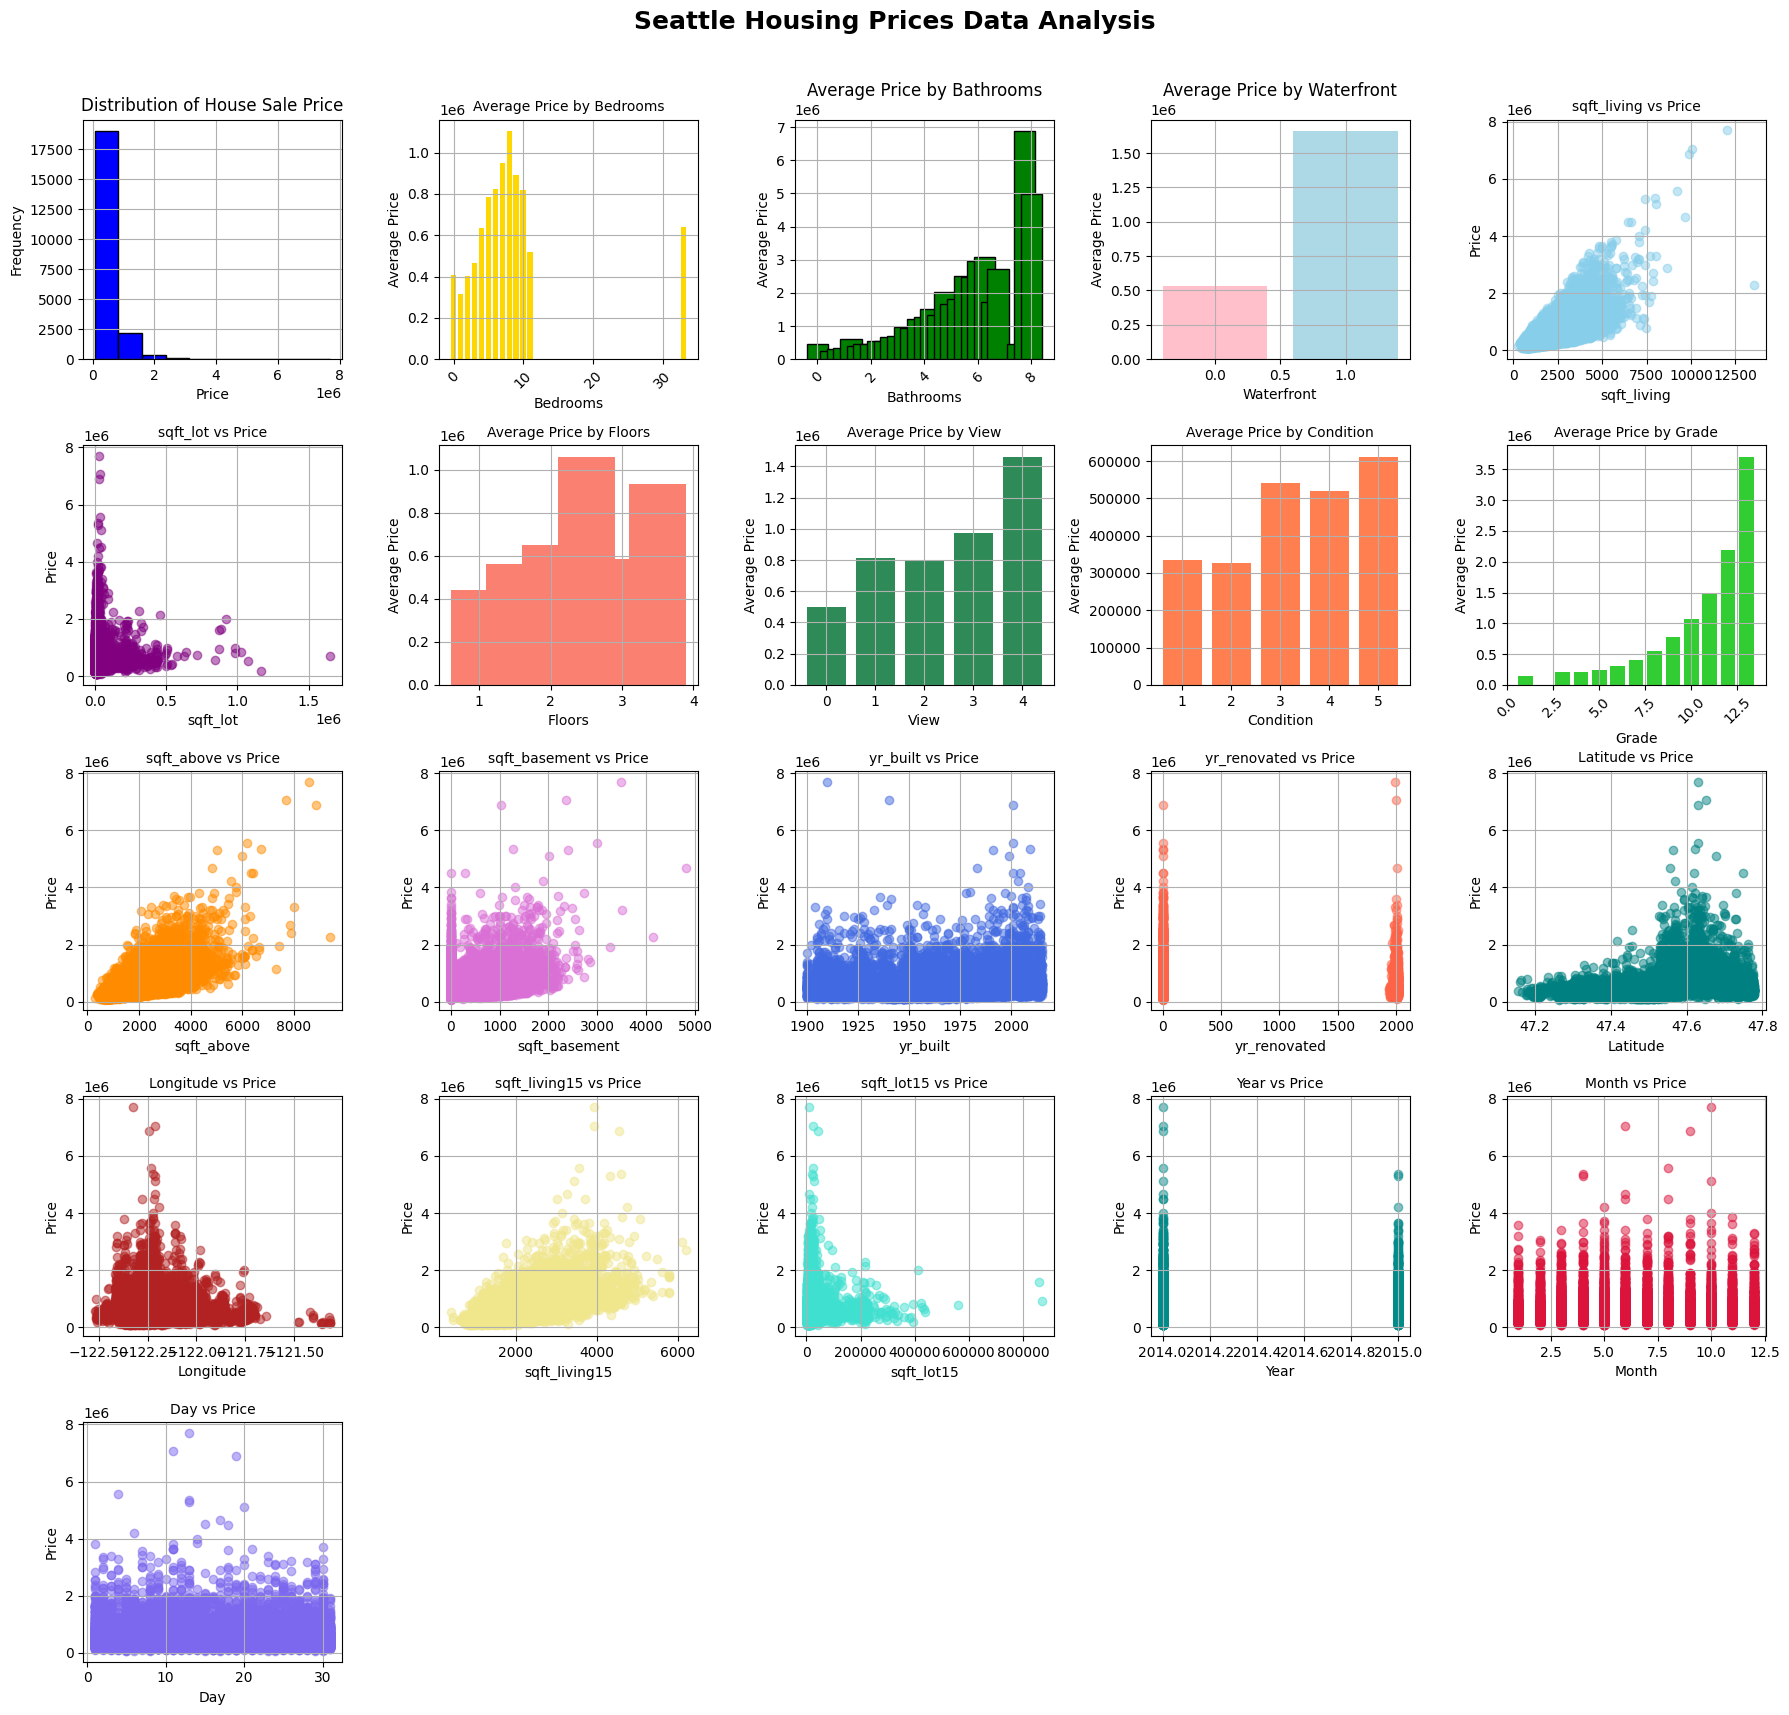

In [69]:
# Create subplots
fig, axes = plt.subplots(5, 5, figsize=(18, 18))
fig.suptitle('Seattle Housing Prices Data Analysis', fontsize=18, fontweight='bold')

# 1. Histogram of prices
axes[0, 0].hist(df['price'], bins=10, color='b', edgecolor='black')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of House Sale Price')

# 2. Average price by bedrooms
bedroom_avg = df.groupby('bedrooms')['price'].mean()
axes[0, 1].bar(bedroom_avg.index, bedroom_avg.values, color='gold')
axes[0, 1].set_xlabel('Bedrooms')
axes[0, 1].set_ylabel('Average Price')
axes[0, 1].set_title('Average Price by Bedrooms', fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Average price by bathrooms
bathroom_avg = df.groupby('bathrooms')['price'].mean()
axes[0, 2].bar(bathroom_avg.index, bathroom_avg.values, color='green', edgecolor='black')
axes[0, 2].set_xlabel('Bathrooms')
axes[0, 2].set_ylabel('Average Price')
axes[0, 2].set_title('Average Price by Bathrooms')
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Average price by waterfront
waterfront_avg = df.groupby('waterfront')['price'].mean()
axes[0, 3].bar(waterfront_avg.index, waterfront_avg.values, color=['pink', 'lightblue'])
axes[0, 3].set_xlabel('Waterfront')
axes[0, 3].set_ylabel('Average Price')
axes[0, 3].set_title('Average Price by Waterfront')

# 5. sqft_living vs price
axes[0, 4].scatter(df['sqft_living'], df['price'], alpha=0.5, color='skyblue')
axes[0, 4].set_xlabel('sqft_living')
axes[0, 4].set_ylabel('Price')
axes[0, 4].set_title('sqft_living vs Price', fontsize=10)


# ROW 2
# 6. sqft_lot vs price
axes[1, 0].scatter(df['sqft_lot'], df['price'], alpha=0.5, color='purple')
axes[1, 0].set_xlabel('sqft_lot')
axes[1, 0].set_ylabel('Price')
axes[1, 0].set_title('sqft_lot vs Price', fontsize=10)

# 7. Average price by floors
floors_avg = df.groupby('floors')['price'].mean()
axes[1, 1].bar(floors_avg.index, floors_avg.values, color='salmon')
axes[1, 1].set_xlabel('Floors')
axes[1, 1].set_ylabel('Average Price')
axes[1, 1].set_title('Average Price by Floors', fontsize=10)

# 8. Average price by view
view_avg = df.groupby('view')['price'].mean()
axes[1, 2].bar(view_avg.index, view_avg.values, color='seagreen')
axes[1, 2].set_xlabel('View')
axes[1, 2].set_ylabel('Average Price')
axes[1, 2].set_title('Average Price by View', fontsize=10)

# 9. Average price by condition
condition_avg = df.groupby('condition')['price'].mean()
axes[1, 3].bar(condition_avg.index, condition_avg.values, color='coral')
axes[1, 3].set_xlabel('Condition')
axes[1, 3].set_ylabel('Average Price')
axes[1, 3].set_title('Average Price by Condition', fontsize=10)

# 10. Average price by grade
grade_avg = df.groupby('grade')['price'].mean()
axes[1, 4].bar(grade_avg.index, grade_avg.values, color='limegreen')
axes[1, 4].set_xlabel('Grade')
axes[1, 4].set_ylabel('Average Price')
axes[1, 4].set_title('Average Price by Grade', fontsize=10)
axes[1, 4].tick_params(axis='x', rotation=45)


# ROW 3
# 11. sqft_above vs price
axes[2, 0].scatter(df['sqft_above'], df['price'], alpha=0.5, color='darkorange')
axes[2, 0].set_xlabel('sqft_above')
axes[2, 0].set_ylabel('Price')
axes[2, 0].set_title('sqft_above vs Price', fontsize=10)

# 12. sqft_basement vs price
axes[2, 1].scatter(df['sqft_basement'], df['price'], alpha=0.5, color='orchid')
axes[2, 1].set_xlabel('sqft_basement')
axes[2, 1].set_ylabel('Price')
axes[2, 1].set_title('sqft_basement vs Price', fontsize=10)

# 13. yr_built vs price
axes[2, 2].scatter(df['yr_built'], df['price'], alpha=0.5, color='royalblue')
axes[2, 2].set_xlabel('yr_built')
axes[2, 2].set_ylabel('Price')
axes[2, 2].set_title('yr_built vs Price', fontsize=10)

# 14. yr_renovated vs price
axes[2, 3].scatter(df['yr_renovated'], df['price'], alpha=0.5, color='tomato')
axes[2, 3].set_xlabel('yr_renovated')
axes[2, 3].set_ylabel('Price')
axes[2, 3].set_title('yr_renovated vs Price', fontsize=10)

# 15. latitude vs price
axes[2, 4].scatter(df['lat'], df['price'], alpha=0.5, color='teal')
axes[2, 4].set_xlabel('Latitude')
axes[2, 4].set_ylabel('Price')
axes[2, 4].set_title('Latitude vs Price', fontsize=10)


# ROW 4
# 16. longitude vs price
axes[3, 0].scatter(df['long'], df['price'], alpha=0.5, color='firebrick')
axes[3, 0].set_xlabel('Longitude')
axes[3, 0].set_ylabel('Price')
axes[3, 0].set_title('Longitude vs Price', fontsize=10)

# 17. sqft_living15 vs price
axes[3, 1].scatter(df['sqft_living15'], df['price'], alpha=0.5, color='khaki')
axes[3, 1].set_xlabel('sqft_living15')
axes[3, 1].set_ylabel('Price')
axes[3, 1].set_title('sqft_living15 vs Price', fontsize=10)

# 18. sqft_lot15 vs price
axes[3, 2].scatter(df['sqft_lot15'], df['price'], alpha=0.5, color='turquoise')
axes[3, 2].set_xlabel('sqft_lot15')
axes[3, 2].set_ylabel('Price')
axes[3, 2].set_title('sqft_lot15 vs Price', fontsize=10)

# 19. YEAR vs price
axes[3, 3].scatter(df['year'], df['price'], alpha=0.5, color='darkcyan')
axes[3, 3].set_xlabel('Year')
axes[3, 3].set_ylabel('Price')
axes[3, 3].set_title('Year vs Price', fontsize=10)

# 20. MONTH vs price
axes[3, 4].scatter(df['month'], df['price'], alpha=0.5, color='crimson')
axes[3, 4].set_xlabel('Month')
axes[3, 4].set_ylabel('Price')
axes[3, 4].set_title('Month vs Price', fontsize=10)


# ROW 5
# 21. DAY vs price
axes[4, 0].scatter(df['day'], df['price'], alpha=0.5, color='mediumslateblue')
axes[4, 0].set_xlabel('Day')
axes[4, 0].set_ylabel('Price')
axes[4, 0].set_title('Day vs Price', fontsize=10)

# Fill remaining 4 plots with empty axes
axes[4, 1].axis('off')
axes[4, 2].axis('off')
axes[4, 3].axis('off')
axes[4, 4].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()




In [70]:
# in an ideal situation, you would have code similar to this which formats the months and days in a way that indicates that they are looping, but it didn't make a huge difference when tested, and we left it out for simplicity's sake, but be aware that this is something you can do
#df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
#df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

#df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
#df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)


## 4) Prepare X and y
In this section you will prepare your X and Y. X will become all of the features, and Y will contain the target values.

In [71]:
# We don't need this, but be aware that if there is a yes/no or any other binary feature that isn't already formatted as a 0 or 1, we would need to do the binary encoding like this
#df['waterfront'] = df['waterfront'].map({'no': 0, 'yes': 1})

X = df.drop(columns=[target_column]) # X is now all the features (everything except for the target column)
y = df[target_column].astype(float) # Y is the target values converted to float for modeling purposes

# Train/Test split with random state to ensure repeatability. You can change the randomstate in section 0
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state_var
)

# Drop rows with NA remaining in features, if any
# We don't need this section because we did not find any NaNs, but if you switch in another dataset you might find some
#na_rows = X.isna().any(axis=1)
#if na_rows.any():
#    print(f"Dropping {na_rows.sum()} rows with NA in features.")
#    X = X[~na_rows]
#    y = y.loc[X.index]

## 5) Fit LinearRegression

In [72]:
reg = LinearRegression()
reg.fit(X_train, y_train)

print("intercept_ (bias b):", reg.intercept_) # this will give you the intercept point for your model
print("coef_ length:", len(reg.coef_) if hasattr(reg, "coef_") else None) # this will print out how many terms are in the linear regression model

intercept_ (bias b): -106099628.64696689
coef_ length: 89


## 6) Predict and Score

In [73]:
# --- Train Metrics (Linear) ---
y_pred_train_linear = reg.predict(X_train)
r2_train_linear  = r2_score(y_train, y_pred_train_linear)
rmse_train_linear = mean_squared_error(y_train, y_pred_train_linear) ** 0.5
mae_train_linear  = mean_absolute_error(y_train, y_pred_train_linear)

# --- Test Metrics (Linear) ---
y_pred_test_linear = reg.predict(X_test)
r2_test_linear  = r2_score(y_test, y_pred_test_linear)
rmse_test_linear = mean_squared_error(y_test, y_pred_test_linear) ** 0.5
mae_test_linear  = mean_absolute_error(y_test, y_pred_test_linear)

pd.Series({
    "RMSE": round(rmse_test_linear, 2),
    "MAE": round(mae_test_linear, 2),
    "R2 train": round(r2_train_linear, 4),
    "R2 test": round(r2_test_linear, 4)
})



,0
RMSE,149311.2800
MAE,93151.9000
R2 train,0.8089
R2 test,0.8125


We can see from the R<sup>2</sup> that this model isn't a super great fit. It's hard to tell how good the RMSE and MAE are unless we try out the other models, we will not get much data from these two values. We can, however say that the difference between RMSE and MAE is large but not ridiculously large. This could mean that we have some outliers which the model isn't properly taking into account which can't be modeled by a straight line.

## 7) Visualization

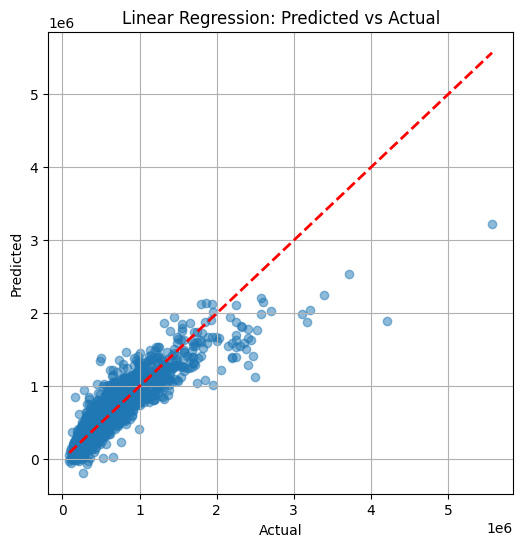

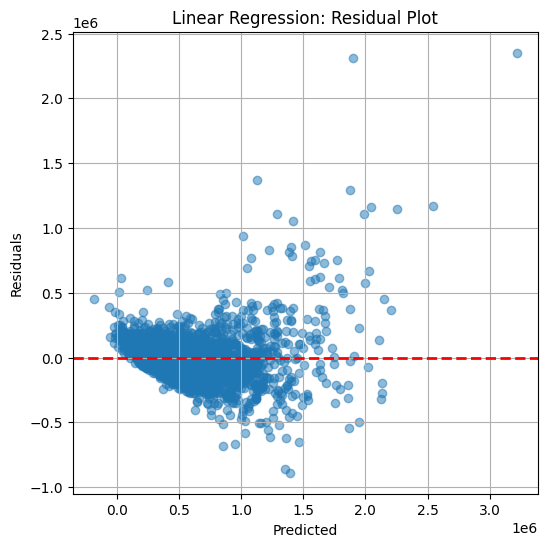

In [74]:
# --- Linear Regression: Predicted vs Actual (Test Set) ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_linear, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Predicted vs Actual")
plt.grid(True)
plt.show()

# --- Linear Regression: Residual Plot ---
residuals_linear = y_test - y_pred_test_linear

plt.figure(figsize=(6,6))
plt.scatter(y_pred_test_linear, residuals_linear, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residual Plot")
plt.grid(True)
plt.show()




## Polynomial Regression (Degree 2)

Sometimes a linear model will not accurately fit the data. A polynomial model can fit the data much better since it can curve rather than being a straight line. We'll start by making one with degree 2, but mess around with `poly_deg` and see if you get different results!

In [75]:
# Try messing around with poly_deg!

# Create a polynomial regression pipeline (degree=2)
poly_deg = 2
poly_reg = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=poly_deg, include_bias=False)),
    ("linreg", LinearRegression())
])
print(f"Created Polynomial Regression pipeline with degree={poly_deg}.")


Created Polynomial Regression pipeline with degree=2.


In [76]:
poly_reg.fit(X_train, y_train)
print("Polynomial model fitted.")

Polynomial model fitted.


In [77]:
# Train Metrics (Poly)
y_pred_train_poly = poly_reg.predict(X_train)
r2_train_poly  = r2_score(y_train, y_pred_train_poly)
rmse_train_poly = mean_squared_error(y_train, y_pred_train_poly) ** 0.5
mae_train_poly  = mean_absolute_error(y_train, y_pred_train_poly)

# Test Metrics (Poly)
y_pred_test_poly = poly_reg.predict(X_test)
r2_test_poly  = r2_score(y_test, y_pred_test_poly)
rmse_test_poly = mean_squared_error(y_test, y_pred_test_poly) ** 0.5
mae_test_poly  = mean_absolute_error(y_test, y_pred_test_poly)

pd.Series({
    "RMSE": round(rmse_test_poly, 2),
    "MAE": round(mae_test_poly, 2),
    "R2 train": round(r2_train_poly, 4),
    "R2 test": round(r2_test_poly, 4)
})

,0
RMSE,112012.7100
MAE,66380.8300
R2 train,0.9363
R2 test,0.8945


Now, you might have been unable to get past this part if you set up your data correctly. Google Colab only gives you 12GB of RAM, which is a lot, but polynomial regression takes a very large amount of RAM. If you are having strange errors, it is likely that you are overloading the RAM of the hardware Colab gives you. If you are able to get it to run with degree 2, it will actually be the second best model of all the models tested.

This leaves you with a predicament: you can either remove features, affecting the integrity of the data, or you can make the decision that polynomial regression does not fit your use case. This is a decision that sometimes has to be made when working with the constraints of your organization.

If you are able to get Polynomial running, you will see that the disparity between MAE and RMSE is around 100%, which means that Polynomial regression is not capturing the outliers quite as well as some of the other models.

Polynomial does however have excellent fit, with R<sup>2</sup> test being 0.8945. There is a little bit of overfitting though, with the training R<sup>2</sup> being 0.9363. This, however, isn't horrible, and shouldn't be a cause of concern.

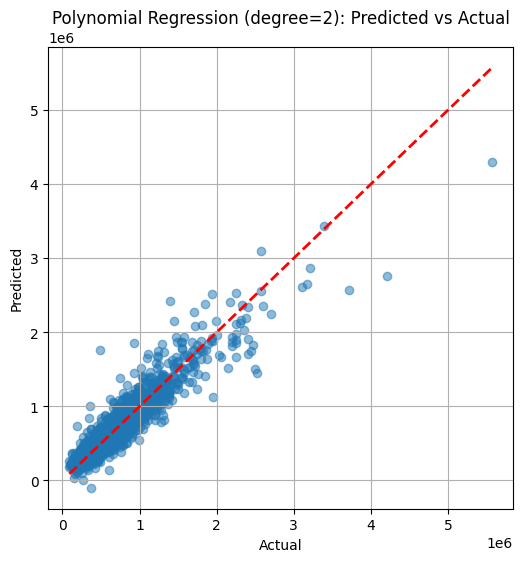

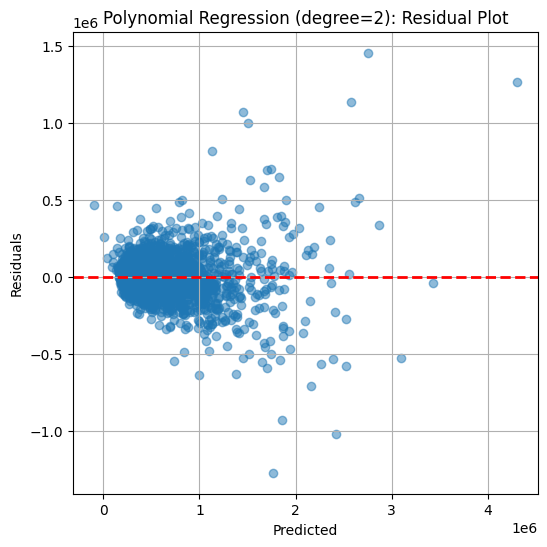

In [78]:
# --- Polynomial Regression: Predicted vs Actual (Test Set) ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_poly, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Polynomial Regression (degree={poly_deg}): Predicted vs Actual")
plt.grid(True)
plt.show()

# --- Polynomial Regression: Residual Plot ---
residuals_poly = y_test - y_pred_test_poly

plt.figure(figsize=(6,6))
plt.scatter(y_pred_test_poly, residuals_poly, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title(f"Polynomial Regression (degree={poly_deg}): Residual Plot")
plt.grid(True)
plt.show()



## Ridge Regression

In [79]:
# Try changing alpha!
alpha_ridge = 0.0001

# Create a pipeline that scales before fitting Ridge
ridge_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=alpha_ridge))
])


In [80]:
# Fit pipeline on training data
ridge_pipe.fit(X_train, y_train);

In [81]:
# Train Metrics (Ridge)
y_pred_train_ridge = ridge_pipe.predict(X_train)
r2_train_ridge  = r2_score(y_train, y_pred_train_ridge)
rmse_train_ridge = mean_squared_error(y_train, y_pred_train_ridge) ** 0.5
mae_train_ridge  = mean_absolute_error(y_train, y_pred_train_ridge)

# Test Metrics (Ridge)
y_pred_test_ridge = ridge_pipe.predict(X_test)
r2_test_ridge  = r2_score(y_test, y_pred_test_ridge)
rmse_test_ridge = mean_squared_error(y_test, y_pred_test_ridge) ** 0.5
mae_test_ridge  = mean_absolute_error(y_test, y_pred_test_ridge)

pd.Series({
    "RMSE": round(rmse_test_ridge, 2),
    "MAE": round(mae_test_ridge, 2),
    "R2 train": round(r2_train_ridge, 4),
    "R2 test": round(r2_test_ridge, 4)
})

,0
RMSE,149311.2800
MAE,93151.9000
R2 train,0.8089
R2 test,0.8125


Here we can see that the R<sup>2</sup> train and the R<sup>2</sup> test are nearly identical. This means that there is no overfitting being done by Ridge Regression.

RMSE and MAE look okay, although the disparity between them is a little larger than one would hope for being over 50% difference, but it falls on the better end of the disparity compared to the other models, indicating it produces fewer large errors

## Ridge Regression: Actual vs Predicted



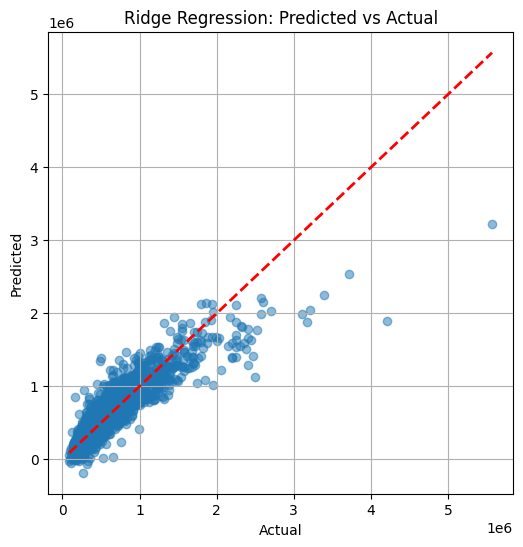

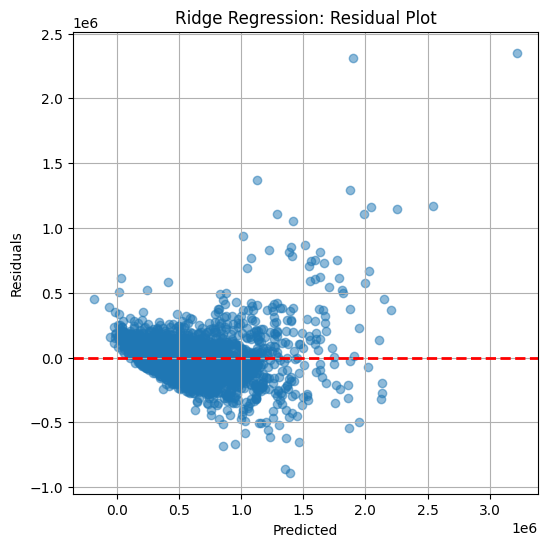

In [82]:
# --- Ridge: Predicted vs Actual & Residual Plot ---

# Predicted vs Actual (Test set)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test_ridge, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge Regression: Predicted vs Actual")
plt.grid(True)
plt.show()

# Residual plot (Test set)
residuals_ridge = y_test - y_pred_test_ridge

plt.figure(figsize=(6, 6))
plt.scatter(y_pred_test_ridge, residuals_ridge, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Ridge Regression: Residual Plot")
plt.grid(True)
plt.show()



## KNN (K-Nearest Neighbors)

In [83]:
# Try changing n_neighbors_knn!
n_neighbors_knn = 7

knn_fast = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=n_neighbors_knn, weights="distance", p=2))
])


In [84]:
knn_fast.fit(X_train, y_train);

In [85]:
# --- Train Metrics (KNN) ---
y_pred_train_knn = knn_fast.predict(X_train)
r2_train_knn  = r2_score(y_train, y_pred_train_knn)
rmse_train_knn = mean_squared_error(y_train, y_pred_train_knn) ** 0.5
mae_train_knn  = mean_absolute_error(y_train, y_pred_train_knn)

# --- Test Metrics (KNN) ---
y_pred_test_knn = knn_fast.predict(X_test)
r2_test_knn  = r2_score(y_test, y_pred_test_knn)
rmse_test_knn = mean_squared_error(y_test, y_pred_test_knn) ** 0.5
mae_test_knn  = mean_absolute_error(y_test, y_pred_test_knn)

pd.Series({
    "RMSE": round(rmse_test_knn, 2),
    "MAE": round(mae_test_knn, 2),
    "R2 train": round(r2_train_knn, 4),
    "R2 test": round(r2_test_knn, 4)
})

,0
RMSE,147373.3200
MAE,79130.6700
R2 train,1.0000
R2 test,0.8174


kNN gives some interesting results. While the R<sup>2</sup> train is exactly 1, showing a perfect fit with the training data, the R<sup>2</sup> test is horribe by comparison. This is a perfect example of overfitting.

If we look at RMSE and MAE, they are also not great, with RMSE being around 100% larger than MAE, showing that the model has some predictions that are very far off, putting this model on the worse end when it comes to large outliers

## KNN: Actual vs. Predicted

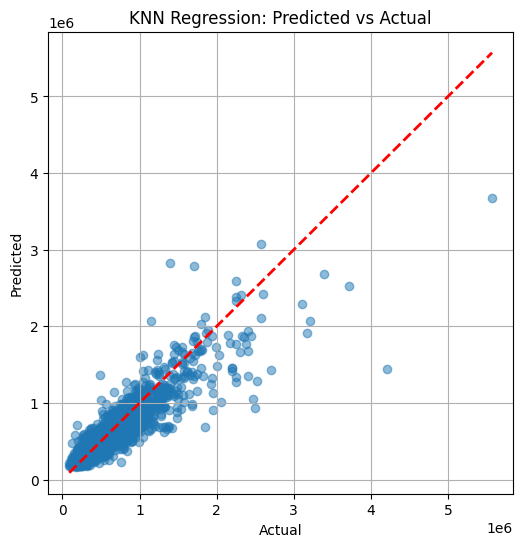

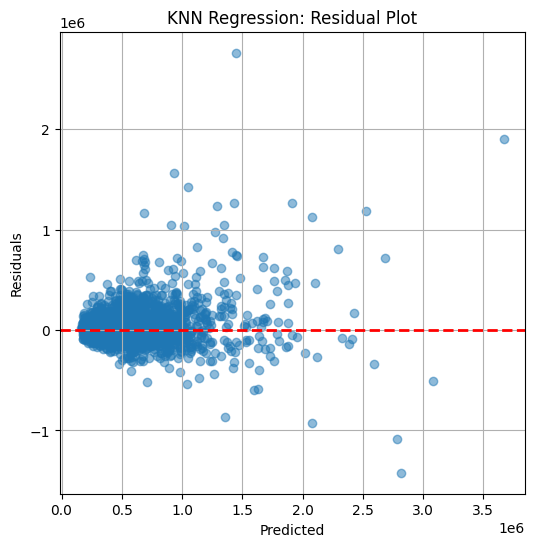

In [86]:
# --- KNN Regression: Predicted vs Actual (Test Set) ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_knn, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("KNN Regression: Predicted vs Actual")
plt.grid(True)
plt.show()

# --- KNN Regression: Residual Plot (Test Set) ---
residuals_knn = y_test - y_pred_test_knn

plt.figure(figsize=(6,6))
plt.scatter(y_pred_test_knn, residuals_knn, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("KNN Regression: Residual Plot")
plt.grid(True)
plt.show()


In [87]:
# --- Lasso Regression ---

# Try changing alpha!
# You can also try changing the max iterations if you want
alpha_lasso = 0.001
max_iter_lasso = 10000

# Create a pipeline that scales before fitting Lasso
lasso_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=alpha_lasso, max_iter=max_iter_lasso, random_state=random_state_var))
])


In [88]:
# Fit pipeline on training data
lasso_pipe.fit(X_train, y_train);

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.599e+13, tolerance: 2.398e+11
  model = cd_fast.enet_coordinate_descent(


In [89]:
# --- Train Metrics (Lasso) ---
y_pred_train_lasso = lasso_pipe.predict(X_train)
r2_train_lasso  = r2_score(y_train, y_pred_train_lasso)
rmse_train_lasso = mean_squared_error(y_train, y_pred_train_lasso) ** 0.5
mae_train_lasso  = mean_absolute_error(y_train, y_pred_train_lasso)

# --- Test Metrics (Lasso) ---
y_pred_test_lasso = lasso_pipe.predict(X_test)
r2_test_lasso  = r2_score(y_test, y_pred_test_lasso)
rmse_test_lasso = mean_squared_error(y_test, y_pred_test_lasso) ** 0.5
mae_test_lasso  = mean_absolute_error(y_test, y_pred_test_lasso)

pd.Series({
    "RMSE": round(rmse_test_lasso, 2),
    "MAE": round(mae_test_lasso, 2),
    "R2 train": round(r2_train_lasso, 4),
    "R2 test": round(r2_test_lasso, 4)
})

,0
RMSE,149311.2800
MAE,93151.9100
R2 train,0.8089
R2 test,0.8125


Here we can see that the R<sup>2</sup> train and R<sup>2</sup> test for Lasso are also very close to one another, which tells us that Lasso is not overfitting and is generalizing well to the test data. Its overall performance is very similar to Ridge Regression.

RMSE and MAE look reasonable, and the disparity between them is comparable to what we saw with Ridge. This suggests that both models are capturing the data patterns to a similar degree, and that the overall error distribution hasn't changed much. The small differences between the two models come from Lasso's tendency to shrink some coefficients more aggressively, but in this case it doesn't appear to dramatically affect performance.

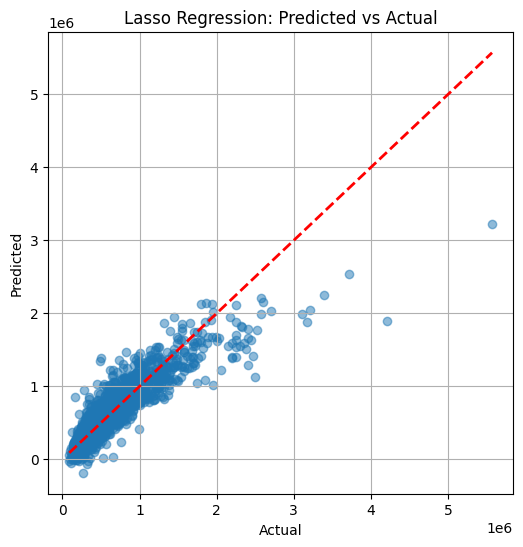

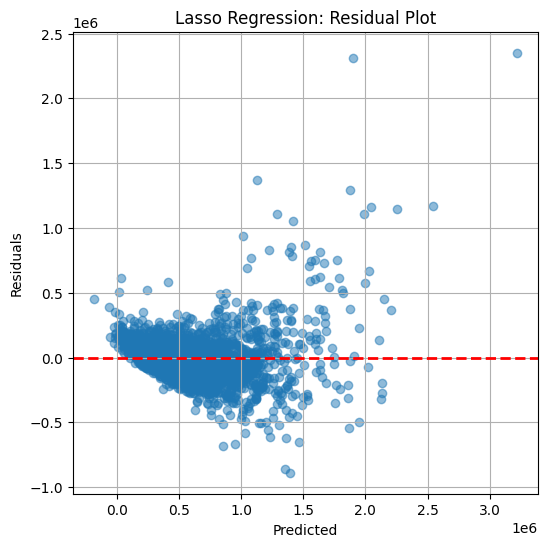

In [90]:
# Predicted vs Actual (Test set)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test_lasso, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso Regression: Predicted vs Actual")
plt.grid(True)
plt.show()

# Residual plot (Test set)
residuals_lasso = y_test - y_pred_test_lasso

plt.figure(figsize=(6, 6))
plt.scatter(y_pred_test_lasso, residuals_lasso, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Lasso Regression: Residual Plot")
plt.grid(True)
plt.show()

# XGBOOST

In [91]:
# Try changing the following parameters!
n_estimators_xgboost = 300
learning_rate_xgboost = 0.05
max_depth_xgboost = 4
subsample_xgboost = 0.8

xgb_reg = XGBRegressor(
    n_estimators=n_estimators_xgboost,
    learning_rate=learning_rate_xgboost,
    max_depth=max_depth_xgboost,
    subsample=subsample_xgboost,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=random_state_var,
    n_jobs=-1
)

In [92]:
xgb_reg.fit(X_train, y_train);

In [93]:
# --- Train Metrics (XGBoost) ---
y_pred_train_xgb = xgb_reg.predict(X_train)
r2_train_xgb  = r2_score(y_train, y_pred_train_xgb)
rmse_train_xgb = mean_squared_error(y_train, y_pred_train_xgb) ** 0.5
mae_train_xgb  = mean_absolute_error(y_train, y_pred_train_xgb)

# --- Test Metrics (XGBoost) ---
y_pred_test_xgb = xgb_reg.predict(X_test)
r2_test_xgb  = r2_score(y_test, y_pred_test_xgb)
rmse_test_xgb = mean_squared_error(y_test, y_pred_test_xgb) ** 0.5
mae_test_xgb  = mean_absolute_error(y_test, y_pred_test_xgb)

pd.Series({
    "RMSE": round(rmse_test_xgb, 2),
    "MAE": round(mae_test_xgb, 2),
    "R2 train": round(r2_train_xgb, 4),
    "R2 test": round(r2_test_xgb, 4)
})


,0
RMSE,111000.2800
MAE,65332.8600
R2 train,0.9377
R2 test,0.8964


Here we can see that the R<sup>2</sup> train and R<sup>2</sup> test values for XGBoost remain close, which means that the model is not overfitting and is still generalizing well. However, both scores are noticeably higher than most other models, indicating that XGBoost is capturing relationships in the data that simpler models cannot.

RMSE and MAE are similarly low to Polynomial Regression. The gap between them is still present, indicating that there are still some large outliers but due to RMSE and MAE being relatively low compared to the other models, it's still an improvement.

# Evaluating XGBoost

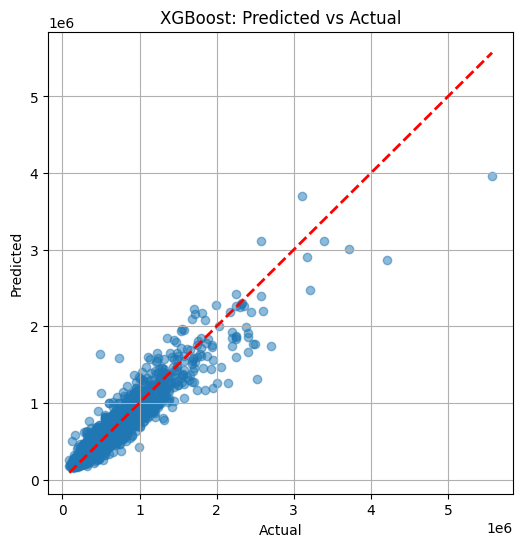

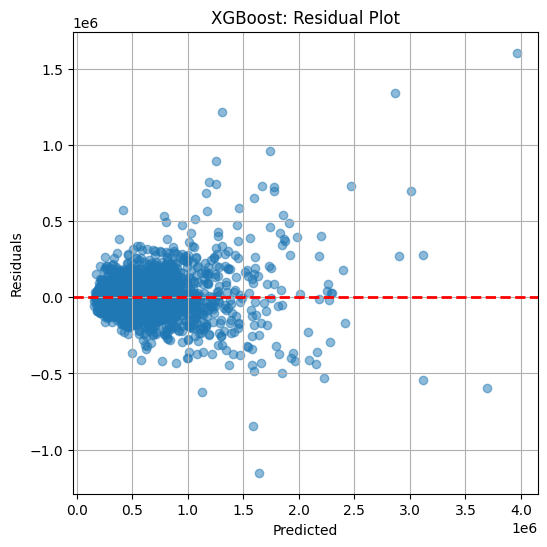

In [94]:
# --- XGBoost: Predicted vs Actual & Residual Plot ---
import matplotlib.pyplot as plt

# Get predictions
y_pred_test_xgb = xgb_reg.predict(X_test)

# --- Predicted vs Actual ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("XGBoost: Predicted vs Actual")
plt.grid(True)
plt.show()

# --- Residual Plot ---
residuals_xgb = y_test - y_pred_test_xgb
plt.figure(figsize=(6,6))
plt.scatter(y_pred_test_xgb, residuals_xgb, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("XGBoost: Residual Plot")
plt.grid(True)
plt.show()


# ELASTIC NET MODEL AND EVALS

In [95]:
# --- Elastic Net Regression ---

# Try changing these!
alpha_enet    = 0.001
l1_ratio_enet = 0.5   # 0 = Ridge-like, 1 = Lasso-like

elastic_net_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("elasticnet", ElasticNet(
        alpha=alpha_enet,
        l1_ratio=l1_ratio_enet,
        max_iter=10000,
        random_state=random_state_var
    ))
])

In [96]:
elastic_net_pipe.fit(X_train, y_train);

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.940e+14, tolerance: 2.398e+11
  model = cd_fast.enet_coordinate_descent(


In [97]:
# --- Train Metrics (Elastic Net) ---
y_pred_train_enet = elastic_net_pipe.predict(X_train)
r2_train_enet  = r2_score(y_train, y_pred_train_enet)
rmse_train_enet = mean_squared_error(y_train, y_pred_train_enet) ** 0.5
mae_train_enet  = mean_absolute_error(y_train, y_pred_train_enet)

# --- Test Metrics (Elastic Net) ---
y_pred_test_enet = elastic_net_pipe.predict(X_test)
r2_test_enet  = r2_score(y_test, y_pred_test_enet)
rmse_test_enet = mean_squared_error(y_test, y_pred_test_enet) ** 0.5
mae_test_enet  = mean_absolute_error(y_test, y_pred_test_enet)

pd.Series({
    "RMSE": round(rmse_test_enet, 2),
    "MAE": round(mae_test_enet, 2),
    "R2 train": round(r2_train_enet, 4),
    "R2 test": round(r2_test_enet, 4)
})


,0
RMSE,149299.7600
MAE,93139.6700
R2 train,0.8089
R2 test,0.8126


Here we can see that the R<sup>2</sup> train and R<sup>2</sup> test values for Elastic Net are nearly identical, which means that the model is not overfitting and is generalizing well to the test data. The performance is very similar to both Ridge and Lasso, which makes sense because Elastic Net blends the two approaches and behaves like a middle ground between them.

RMSE and MAE are almost the same as what we observed with Ridge and Lasso. The disparity between RMSE and MAE is on the better side compared to the other models, indicating that Elastic Net is capturing the same overall error structure without producing unusually large mistakes. Elastic Net performs about on par with the other linear regularization methods, offering no major improvements but maintaining stable and consistent performance.

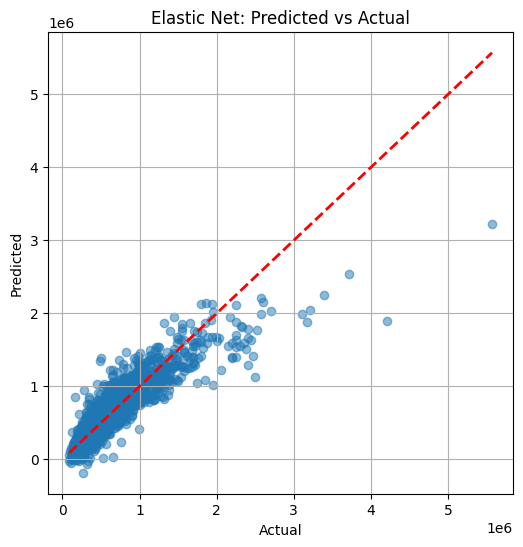

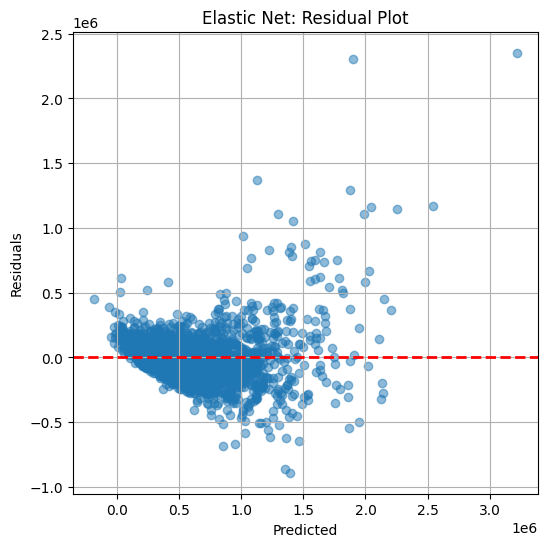

In [98]:
# --- Elastic Net: Predicted vs Actual & Residual Plot ---

# Predictions
y_pred_test_elastic = elastic_net_pipe.predict(X_test)

# --- Predicted vs Actual ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_elastic, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Elastic Net: Predicted vs Actual")
plt.grid(True)
plt.show()

# --- Residual Plot ---
residuals_elastic = y_test - y_pred_test_elastic
plt.figure(figsize=(6,6))
plt.scatter(y_pred_test_elastic, residuals_elastic, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Elastic Net: Residual Plot")
plt.grid(True)
plt.show()


# SVR MODEL AND EVALS

In [99]:
# --- SVR Regression ---

# Try changing these hyperparameters:
C_svr       = 100.0
epsilon_svr = 10
kernel_svr  = "linear"

svr_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svr", SVR(
        C=C_svr,
        epsilon=epsilon_svr,
        kernel=kernel_svr,
    ))
])

In [100]:
svr_pipe.fit(X_train, y_train);

In [101]:
# --- Train Metrics (SVR) ---
y_pred_train_svr = svr_pipe.predict(X_train)
r2_train_svr  = r2_score(y_train, y_pred_train_svr)
rmse_train_svr = mean_squared_error(y_train, y_pred_train_svr) ** 0.5
mae_train_svr  = mean_absolute_error(y_train, y_pred_train_svr)

# --- Test Metrics (SVR) ---
y_pred_test_svr = svr_pipe.predict(X_test)
r2_test_svr  = r2_score(y_test, y_pred_test_svr)
rmse_test_svr = mean_squared_error(y_test, y_pred_test_svr) ** 0.5
mae_test_svr  = mean_absolute_error(y_test, y_pred_test_svr)

pd.Series({
    "RMSE": round(rmse_test_svr, 2),
    "MAE": round(mae_test_svr, 2),
    "R2 train": round(r2_train_svr, 4),
    "R2 test": round(r2_test_svr, 4)
})

,0
RMSE,166262.8900
MAE,83417.3800
R2 train,0.7471
R2 test,0.7676


Here we can see that the R<sup>2</sup> train and R<sup>2</sup> test values for SVR are very close, which means that the model is not overfitting and is generalizing reasonably well. The overall performance, however, is noticeably weaker than many of the other models.

RMSE and MAE are higher compared to all other models which indicates that SVR is making larger prediction errors on average. The disparity between the two error metrics remains similar to the other models, suggesting that the distribution of errors is consistent, but simply larger in magnitude. Overall, SVR does not appear to provide any advantage for this dataset using the default hyperparameters and performs worse than all of the alternatives tested.

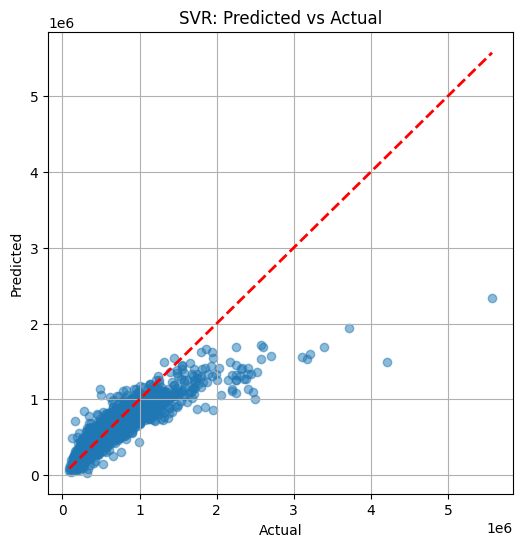

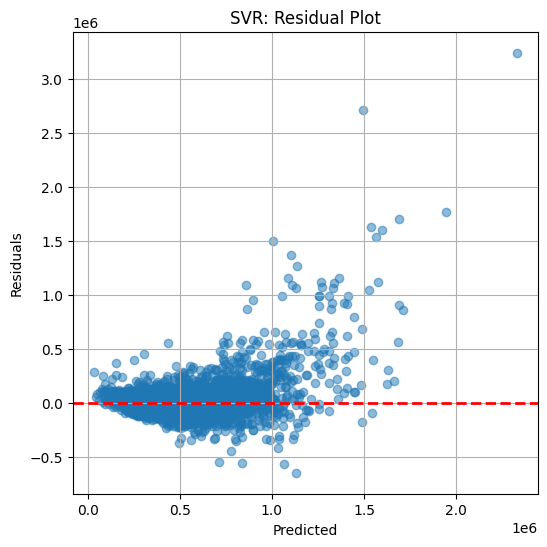

In [102]:
# --- SVR: Predicted vs Actual & Residual Plot ---

# --- Predicted vs Actual ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_svr, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("SVR: Predicted vs Actual")
plt.grid(True)
plt.show()

# --- Residual Plot ---
residuals_svr = y_test - y_pred_test_svr

plt.figure(figsize=(6,6))
plt.scatter(y_pred_test_svr, residuals_svr, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("SVR: Residual Plot")
plt.grid(True)
plt.show()


# DECISION TREE



In [103]:
# --- Decision Tree Regression ---

# Try changing max depth!
tree_max_depth = 10

tree = DecisionTreeRegressor(
    max_depth=tree_max_depth,
    random_state=random_state_var
)

tree.fit(X_train, y_train)

# --- Train Metrics (Decision Tree) ---
y_pred_train_tree = tree.predict(X_train)
r2_train_tree  = r2_score(y_train, y_pred_train_tree)
rmse_train_tree = mean_squared_error(y_train, y_pred_train_tree) ** 0.5
mae_train_tree  = mean_absolute_error(y_train, y_pred_train_tree)

# --- Test Metrics (Decision Tree) ---
y_pred_test_tree = tree.predict(X_test)
r2_test_tree  = r2_score(y_test, y_pred_test_tree)
rmse_test_tree = mean_squared_error(y_test, y_pred_test_tree) ** 0.5
mae_test_tree  = mean_absolute_error(y_test, y_pred_test_tree)

pd.Series({
    "RMSE": round(rmse_test_tree, 2),
    "MAE": round(mae_test_tree, 2),
    "R2 train": round(r2_train_tree, 4),
    "R2 test": round(r2_test_tree, 4)
})



,0
RMSE,156315.3900
MAE,87651.9700
R2 train,0.9129
R2 test,0.7945


Here we can see that the R<sup>2</sup> train score is extremely high while the R<sup>2</sup> test score drops noticeably, which indicates that the Decision Tree model is overfitting. This is expected because decision trees tend to memorize the training data when no depth or splitting constraints are applied.

The RMSE and MAE values are also higher compared to the regularized linear models, showing that the model's predictions are less accurate on unseen data. The gap between RMSE and MAE remains consistent with the other models, but the overall error magnitude is larger. This suggests that although the tree fits the training set very well, it struggles to generalize and does not perform as well on the test set.

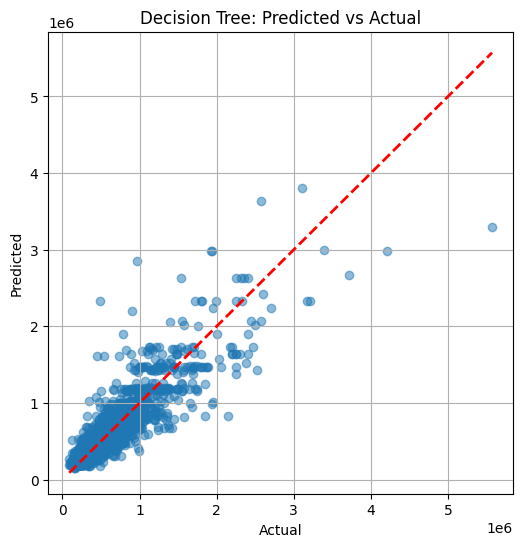

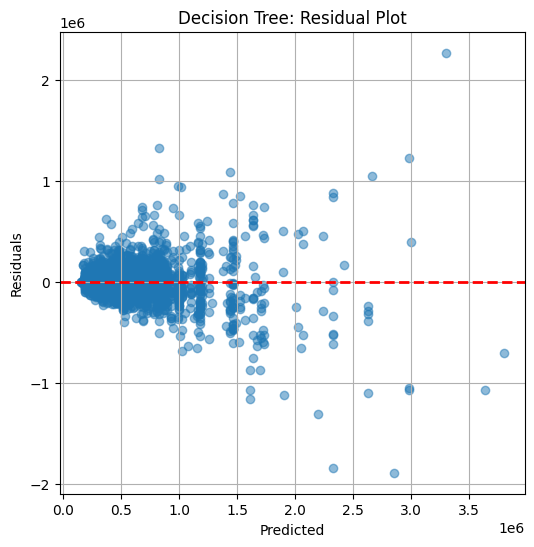

In [104]:
# --- Decision Tree: Predicted vs Actual & Residual Plot ---

# --- Predicted vs Actual ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_tree, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree: Predicted vs Actual")
plt.grid(True)
plt.show()

# --- Residual Plot ---
residuals_tree = y_test - y_pred_test_tree

plt.figure(figsize=(6,6))
plt.scatter(y_pred_test_tree, residuals_tree, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Decision Tree: Residual Plot")
plt.grid(True)
plt.show()

# SGD AND PLOTS

In [105]:
# --- SGD Regression ---

# Try changing alpha!
alpha_sgd = 0.00001

sgd_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("sgd", SGDRegressor(
        alpha=alpha_sgd,
        random_state=random_state_var
    ))
])

In [106]:
sgd_model.fit(X_train, y_train);

In [107]:
# --- Train Metrics (SGD) ---
y_pred_train_sgd = sgd_model.predict(X_train)
r2_train_sgd  = r2_score(y_train, y_pred_train_sgd)
rmse_train_sgd = mean_squared_error(y_train, y_pred_train_sgd) ** 0.5
mae_train_sgd  = mean_absolute_error(y_train, y_pred_train_sgd)

# --- Test Metrics (SGD) ---
y_pred_test_sgd = sgd_model.predict(X_test)
r2_test_sgd  = r2_score(y_test, y_pred_test_sgd)
rmse_test_sgd = mean_squared_error(y_test, y_pred_test_sgd) ** 0.5
mae_test_sgd  = mean_absolute_error(y_test, y_pred_test_sgd)

pd.Series({
    "RMSE": round(rmse_test_sgd, 2),
    "MAE": round(mae_test_sgd, 2),
    "R2 train": round(r2_train_sgd, 4),
    "R2 test": round(r2_test_sgd, 4)
})

,0
RMSE,157437.7600
MAE,105929.1200
R2 train,0.7947
R2 test,0.7916


Here we can see that the R<sup>2</sup> train and R<sup>2</sup> test values for the SGD model are almost identical, which shows that the model is not overfitting and is generalizing consistently. However, the overall performance is weaker compared to the regularized linear models like Ridge, Lasso, and Elastic Net, which all achieved higher R² scores.

RMSE and MAE are also higher than the other linear methods, indicating that SGD is producing larger errors on average. The disparity between RMSE and MAE is on the lower end of the patterns seen in the other models, but the overall magnitude of the errors is noticeably larger. This suggests that while SGD is stable and not behaving erratically, it does not perform as well as the more optimized linear models for this dataset.

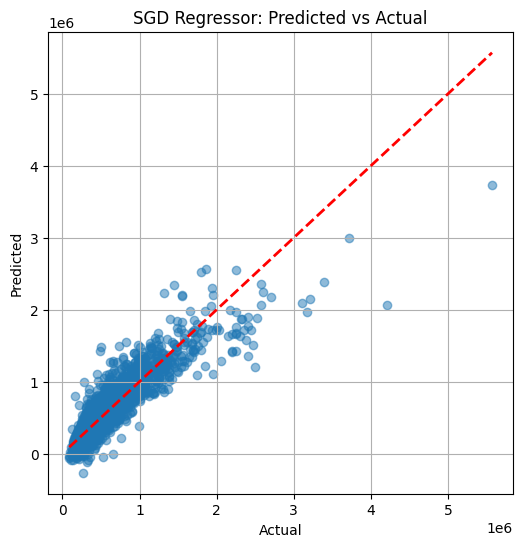

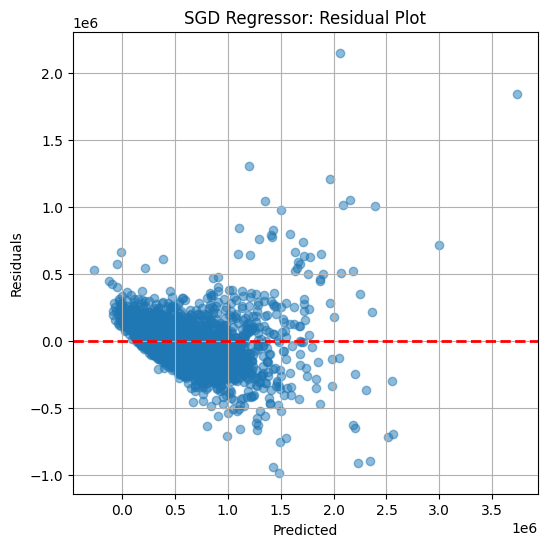

In [108]:
# --- SGD Regressor: Predicted vs Actual & Residual Plot ---

# --- Predicted vs Actual ---
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_sgd, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("SGD Regressor: Predicted vs Actual")
plt.grid(True)
plt.show()

# --- Residual Plot ---
residuals_sgd = y_test - y_pred_test_sgd

plt.figure(figsize=(6,6))
plt.scatter(y_pred_test_sgd, residuals_sgd, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("SGD Regressor: Residual Plot")
plt.grid(True)
plt.show()


In [109]:
rows = []

# 1) Linear Regression
y_pred_test_linear = reg.predict(X_test)
rows.append(["Linear Regression",
             r2_score(y_test, y_pred_test_linear),
             mean_squared_error(y_test, y_pred_test_linear)])

# 2) Polynomial Regression
y_pred_test_poly = poly_reg.predict(X_test)
rows.append(["Polynomial Regression",
        r2_score(y_test, y_pred_test_poly),
        mean_squared_error(y_test, y_pred_test_poly)])

# 3) Lasso Regression
y_pred_test_lasso = lasso_pipe.predict(X_test)
rows.append(["Lasso Regression",
             r2_score(y_test, y_pred_test_lasso),
             mean_squared_error(y_test, y_pred_test_lasso)])

# 4) Ridge Regression
y_pred_test_ridge = ridge_pipe.predict(X_test)
rows.append(["Ridge Regression",
             r2_score(y_test, y_pred_test_ridge),
             mean_squared_error(y_test, y_pred_test_ridge)])

# 5) Elastic Net
y_pred_test_elastic = elastic_net_pipe.predict(X_test)
rows.append(["Elastic Net",
             r2_score(y_test, y_pred_test_elastic),
             mean_squared_error(y_test, y_pred_test_elastic)])

# 6) kNN Regression
y_pred_test_knn = knn_fast.predict(X_test)
rows.append(["kNN Regression",
             r2_score(y_test, y_pred_test_knn),
             mean_squared_error(y_test, y_pred_test_knn)])

# 7) XGBoost Regression
y_pred_test_xgb = xgb_reg.predict(X_test)
rows.append(["XGBoost Regression",
             r2_score(y_test, y_pred_test_xgb),
             mean_squared_error(y_test, y_pred_test_xgb)])

# 8) SVR Regression
y_pred_test = svr_pipe.predict(X_test)
rows.append(["SVR Regression",
             r2_score(y_test, y_pred_test_svr),
             mean_squared_error(y_test, y_pred_test_svr)])

# 9) Decision Tree Regression
y_pred_test_tree = tree.predict(X_test)
rows.append(["Decision Tree Regression",
             r2_score(y_test, y_pred_test_tree),
             mean_squared_error(y_test, y_pred_test_tree)])

# 10) SGD Regression (log target)
y_pred_test_sgd = sgd_model.predict(X_test)
rows.append(["SGD Regressor (log target)",
             r2_score(y_test, y_pred_test_sgd),
             mean_squared_error(y_test, y_pred_test_sgd)])

results = pd.DataFrame(rows, columns=["Model", "Test R2", "Test MSE"])
results = results.sort_values("Test R2", ascending=False).reset_index(drop=True)
results


,Model,Test R2,Test MSE
0,XGBoost Regression,0.896396,1.232106e+10
1,Polynomial Regression,0.894497,1.254685e+10
2,kNN Regression,0.817372,2.171890e+10
3,Elastic Net,0.812566,2.229042e+10
4,Lasso Regression,0.812537,2.229386e+10
5,Ridge Regression,0.812537,2.229386e+10
6,Linear Regression,0.812537,2.229386e+10
7,Decision Tree Regression,0.794537,2.443450e+10
8,SGD Regressor (log target),0.791576,2.478665e+10
9,SVR Regression,0.767555,2.764335e+10


Model Performance Comparison
                     Model          MSE          RMSE           MAE       R2
         Linear Regression 2.229386e+10 149311.284682  93151.904966 0.812537
     Polynomial Regression 1.254685e+10 112012.709274  66380.834401 0.894497
          Lasso Regression 2.229386e+10 149311.283983  93151.905334 0.812537
          Ridge Regression 2.229386e+10 149311.284477  93151.904750 0.812537
               Elastic Net 2.229042e+10 149299.764264  93139.667135 0.812566
            kNN Regression 2.171890e+10 147373.324994  79130.673868 0.817372
        XGBoost Regression 1.232106e+10 111000.278651  65332.860358 0.896396
            SVR Regression 2.764335e+10 166262.890729  83417.379413 0.767555
  Decision Tree Regression 2.443450e+10 156315.392040  87651.969540 0.794537
SGD Regressor (log target) 2.478665e+10 157437.758810 105929.123436 0.791576


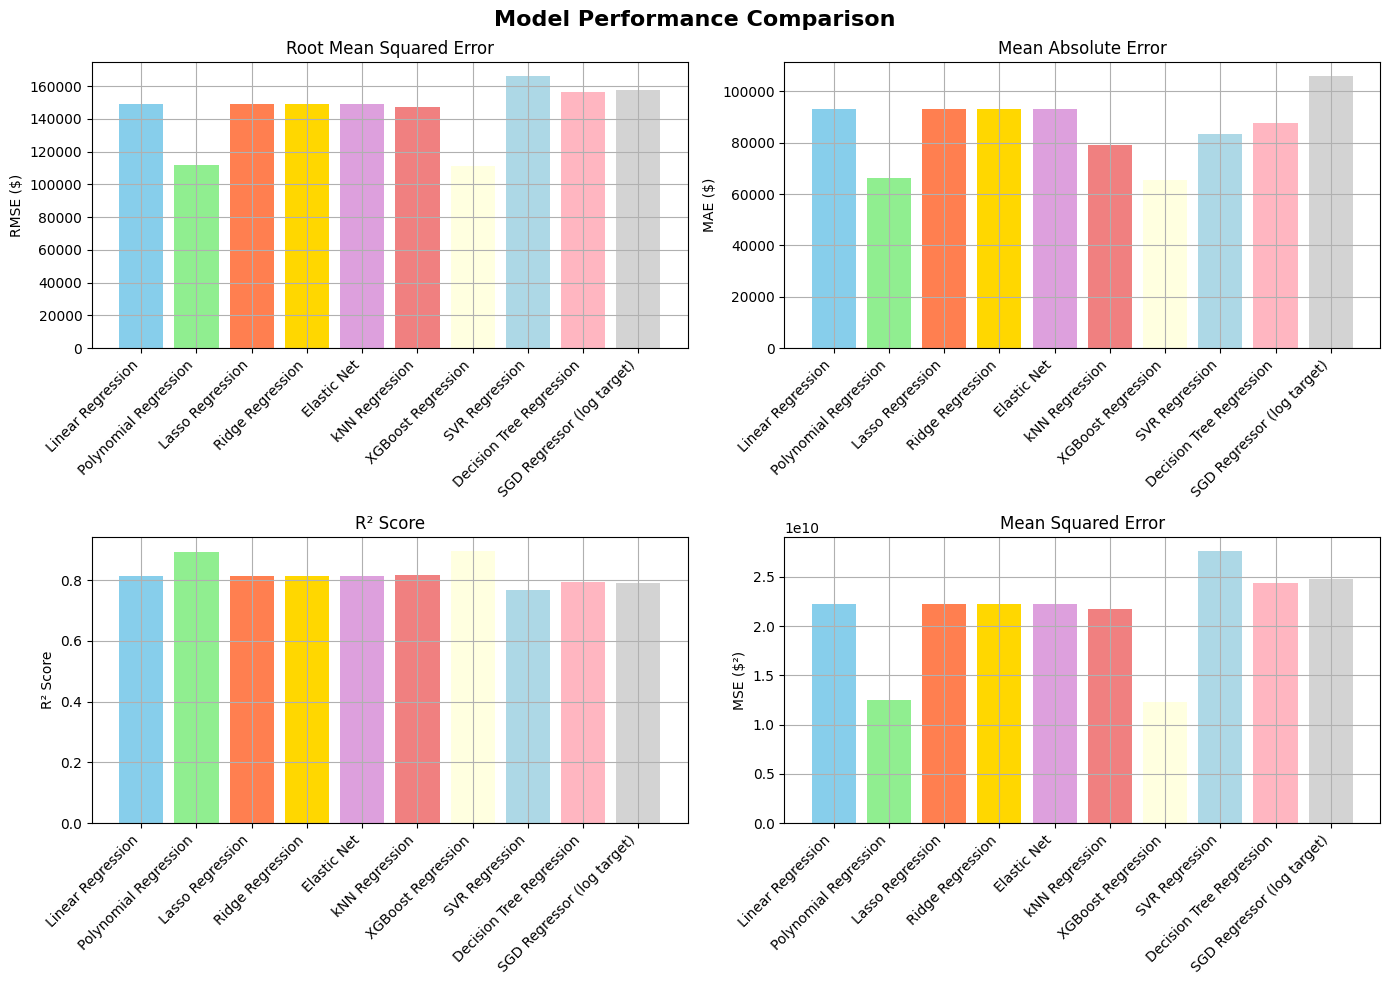

In [110]:
# Store model names and predictions
model_names = [
    'Linear Regression',
    'Polynomial Regression',
    'Lasso Regression',
    'Ridge Regression',
    'Elastic Net',
    'kNN Regression',
    'XGBoost Regression',
    'SVR Regression',
    'Decision Tree Regression',
    'SGD Regressor (log target)'
]

# Generate predictions for each model
predictions = [
    reg.predict(X_test),
    poly_reg.predict(X_test),
    lasso_pipe.predict(X_test),
    ridge_pipe.predict(X_test),
    elastic_net_pipe.predict(X_test),
    knn_fast.predict(X_test),
    xgb_reg.predict(X_test),
    y_pred_test_svr,  # SVR (already computed)
    tree.predict(X_test),
    y_pred_test_sgd   # SGD (already computed)
]

# Calculate metrics for all models
models_data = {
    'Model': model_names,
    'MSE': [mean_squared_error(y_test, pred) for pred in predictions],
    'RMSE': [np.sqrt(mean_squared_error(y_test, pred)) for pred in predictions],
    'MAE': [mean_absolute_error(y_test, pred) for pred in predictions],
    'R2': [r2_score(y_test, pred) for pred in predictions]
}

comparison_df = pd.DataFrame(models_data)

print("Model Performance Comparison")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Define colors for all 10 models
colors = ['skyblue', 'lightgreen', 'coral', 'gold', 'plum',
          'lightcoral', 'lightyellow', 'lightblue', 'lightpink', 'lightgray']

# RMSE comparison
axes[0, 0].bar(comparison_df['Model'], comparison_df['RMSE'], color=colors)
axes[0, 0].set_ylabel('RMSE ($)')
axes[0, 0].set_title('Root Mean Squared Error')
axes[0, 0].tick_params(axis='x', rotation=45)
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')


# MAE comparison
axes[0, 1].bar(comparison_df['Model'], comparison_df['MAE'], color=colors)
axes[0, 1].set_ylabel('MAE ($)')
axes[0, 1].set_title('Mean Absolute Error')
axes[0, 1].tick_params(axis='x', rotation=45)
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')


# R2 comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['R2'], color=colors)
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_title('R² Score')
axes[1, 0].tick_params(axis='x', rotation=45)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')


# MSE comparison
axes[1, 1].bar(comparison_df['Model'], comparison_df['MSE'], color=colors)
axes[1, 1].set_ylabel('MSE ($²)')
axes[1, 1].set_title('Mean Squared Error')
axes[1, 1].tick_params(axis='x', rotation=45)
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')


plt.tight_layout()
plt.show()

We can see that every model had variations in how well they fit to different metrics. We can see that the disparity between RMSE and MAE is present with every model, but fairly consistently so with each model.

If you used the default hyperparameters that were set in this notebook, you should have found that XGboost is the best by every metric, producing the lowest error values and the highest R<sup>2</sup>, showing that XGBoost more accurately models the data than the other models.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.291e+14, tolerance: 2.398e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.287e+14, tolerance: 2.398e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.107e+14, tolerance: 2.398e

Hyperparameter Tuning Results
                Model          RMSE          MAE       R2
Polynomial (degree=2) 117693.813681 70285.993855 0.883524
    Ridge (alpha=0.1) 149311.911459 93161.241858 0.812536
    Ridge (alpha=1.0) 149406.142325 93250.908197 0.812299
     Ridge (alpha=10) 150281.384369 93479.340476 0.810093
    Ridge (alpha=100) 160765.163463 98942.447380 0.782673
    Lasso (alpha=0.1) 149310.363648 93152.472623 0.812540
    Lasso (alpha=1.0) 149308.318892 93159.509642 0.812545
     Lasso (alpha=10) 149347.652194 93192.200324 0.812446
    Lasso (alpha=100) 149627.775472 93148.274403 0.811742


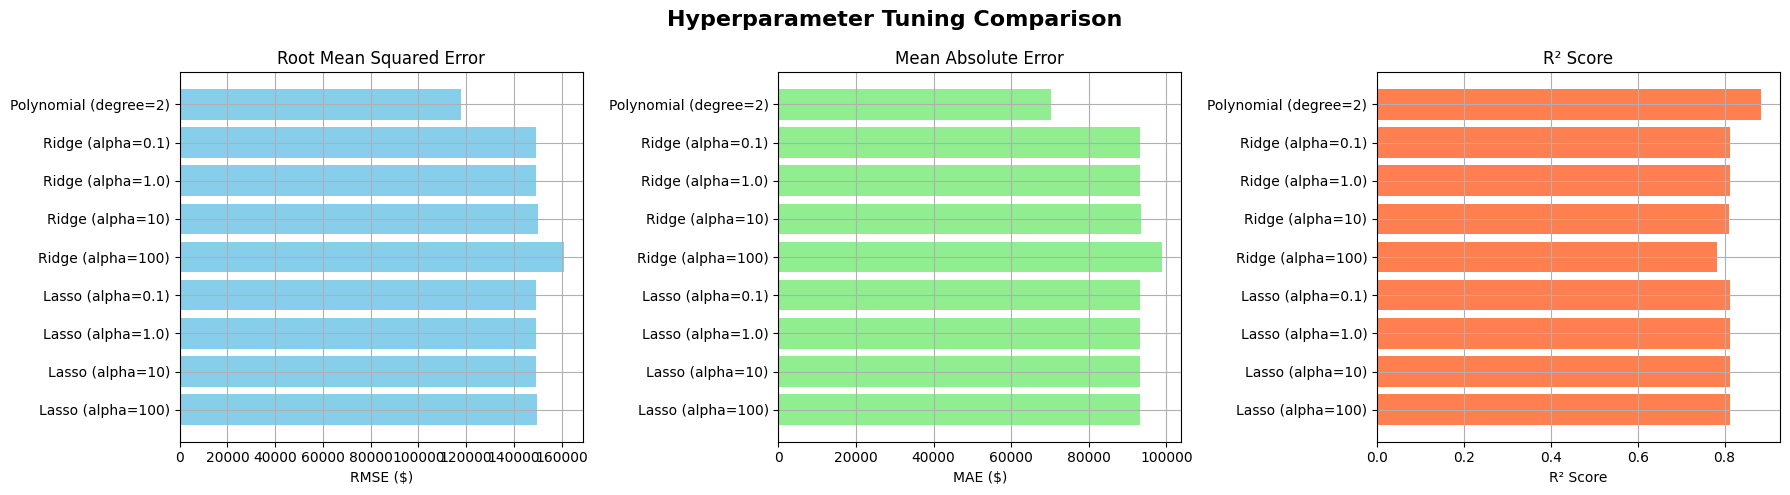

In [111]:
# Hyperparameter exploration: Polynomial degree, Ridge alpha, Lasso alpha
tuning_results = []

# --- Polynomial Regression with different degrees ---
# If you have trouble with this part, go to the section "Issues with Polynomial Regression," and make the instructed changes there. This will make all models not as accurate, but will allow you to see the differences between different degree. You can also just remove the 3 and 4 and just compare polynomial with degree 2 to the others, degree 2 typically works
for degree in [2]:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)

    # Use the same top correlated numeric features as earlier
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly  = poly_features.transform(X_test)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_tune = poly_model.predict(X_test_poly)

    tuning_results.append({
        'Model': f'Polynomial (degree={degree})',
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_tune)),
        'MAE': mean_absolute_error(y_test, y_pred_tune),
        'R2': r2_score(y_test, y_pred_tune)
    })

# --- Ridge Regression with different alphas (on X_train / X_test) ---
for alpha in [0.1, 1.0, 10, 100]:
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    y_pred_tune = ridge_model.predict(X_test)

    tuning_results.append({
        'Model': f'Ridge (alpha={alpha})',
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_tune)),
        'MAE': mean_absolute_error(y_test, y_pred_tune),
        'R2': r2_score(y_test, y_pred_tune)
    })

# --- Lasso Regression with different alphas (on X_train / X_test) ---
for alpha in [0.1, 1.0, 10, 100]:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train, y_train)
    y_pred_tune = lasso_model.predict(X_test)

    tuning_results.append({
        'Model': f'Lasso (alpha={alpha})',
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_tune)),
        'MAE': mean_absolute_error(y_test, y_pred_tune),
        'R2': r2_score(y_test, y_pred_tune)
    })

# --- Create comparison DataFrame ---
tuning_df = pd.DataFrame(tuning_results)

print("Hyperparameter Tuning Results")
print("=" * 70)
print(tuning_df.to_string(index=False))

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Hyperparameter Tuning Comparison', fontsize=16, fontweight='bold')

# RMSE comparison
axes[0].barh(tuning_df['Model'], tuning_df['RMSE'], color='skyblue')
axes[0].set_xlabel('RMSE ($)')
axes[0].set_title('Root Mean Squared Error')
axes[0].invert_yaxis()

# MAE comparison
axes[1].barh(tuning_df['Model'], tuning_df['MAE'], color='lightgreen')
axes[1].set_xlabel('MAE ($)')
axes[1].set_title('Mean Absolute Error')
axes[1].invert_yaxis()

# R2 comparison
axes[2].barh(tuning_df['Model'], tuning_df['R2'], color='coral')
axes[2].set_xlabel('R² Score')
axes[2].set_title('R² Score')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


A lot of the differences between models can be hard to see, so try changing the models used in these charts, as well as changing the variables like the number of bins and alpha.

Line and scatter plots are not always the best way to see the performance of your data. It's more important for you to understand what the data is doing than for you to view the data in a particular way, be creative and find better ways to understand the data!

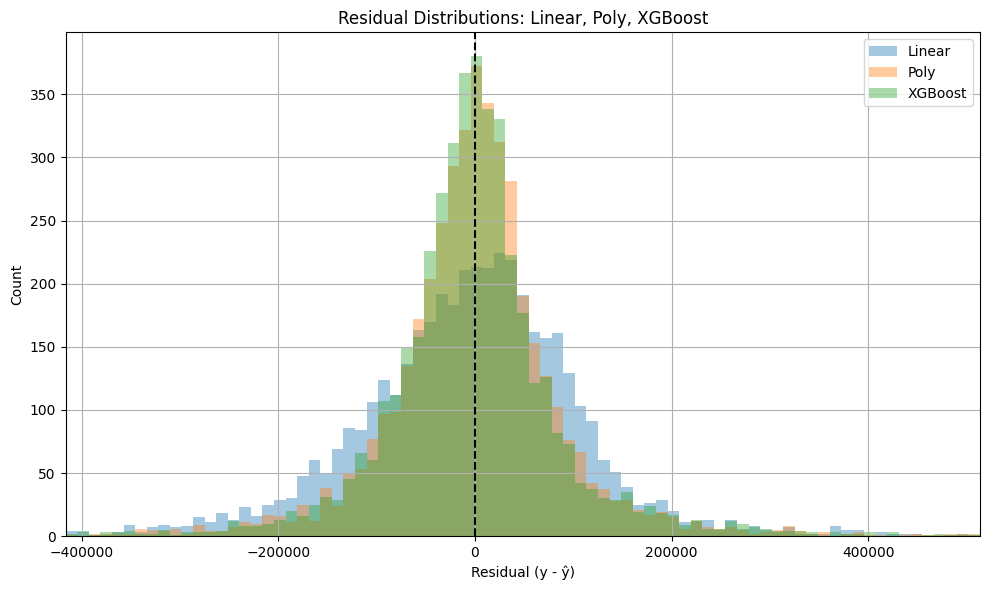

/tmp/ipython-input-429812004.py:95: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(selected_residual_sets, labels=valid_model_names, showfliers=True)


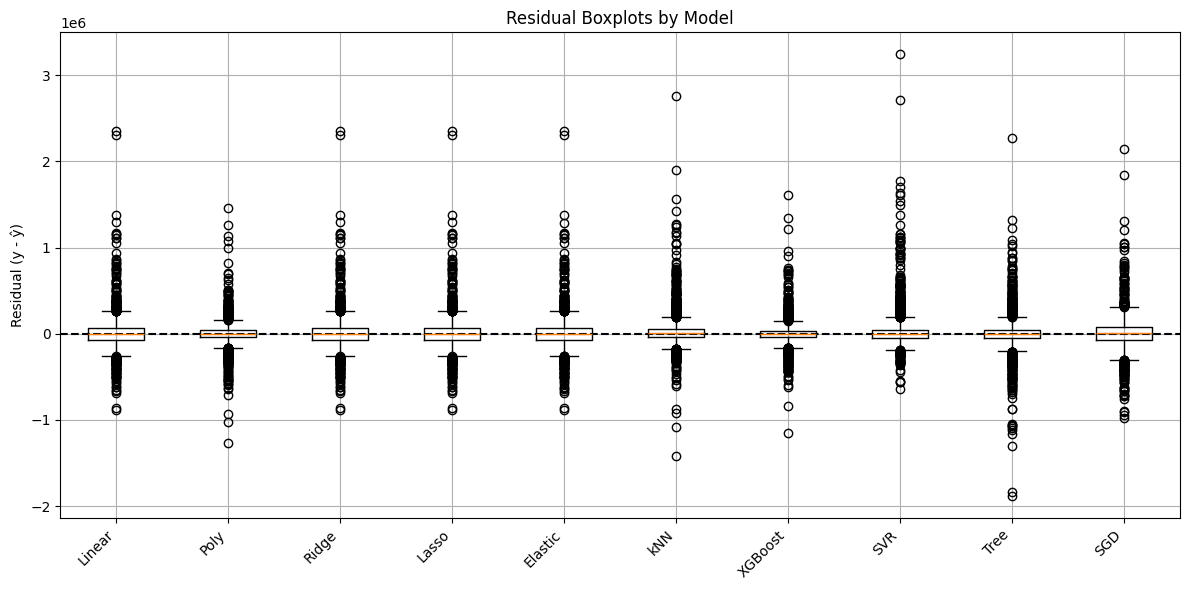

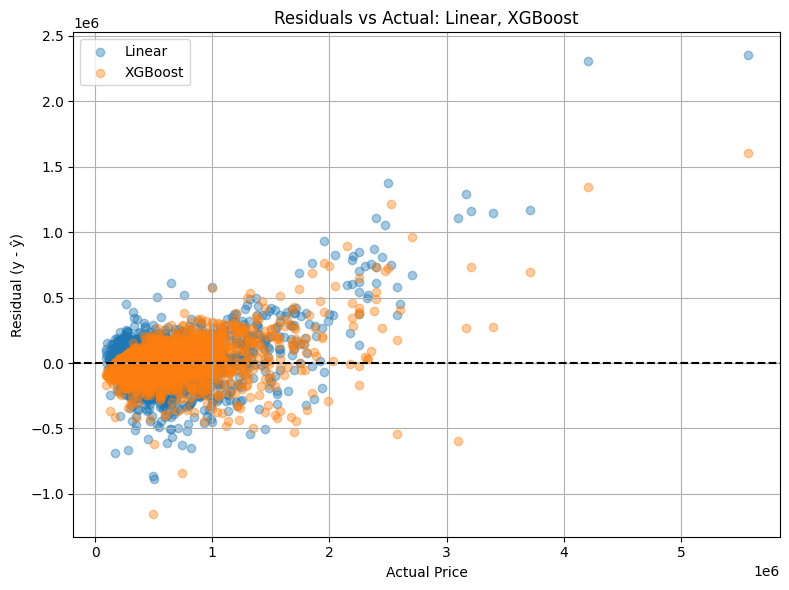

In [112]:
# ---------- 1) Create unified residual variables ----------

residuals_linear   = y_test - y_pred_test_linear
residuals_poly     = y_test - y_pred_test_poly
residuals_ridge    = y_test - y_pred_test_ridge
residuals_lasso    = y_test - y_pred_test_lasso
residuals_elastic  = y_test - y_pred_test_elastic
residuals_knn      = y_test - y_pred_test_knn
residuals_xgb      = y_test - y_pred_test_xgb
residuals_svr      = y_test - y_pred_test_svr
residuals_tree     = y_test - y_pred_test_tree
residuals_sgd      = y_test - y_pred_test_sgd

# ============================================================
# Dictionary mapping model names to their residuals
# ============================================================

residuals = {
    "Linear": residuals_linear,
    "Poly": residuals_poly,
    "Ridge": residuals_ridge,
    "Lasso": residuals_lasso,
    "Elastic": residuals_elastic,
    "kNN": residuals_knn,
    "XGBoost": residuals_xgb,
    "SVR": residuals_svr,
    "Tree": residuals_tree,
    "SGD": residuals_sgd
}

# ---------- 2) Residual histograms ----------


# You can put whichever models you want to compare here, make sure it lines up with the value in the residuals dictionary

models_to_plot_histogram = ["Linear", "Poly", "XGBoost"]  # <-- Edit these

# Collect residuals for only selected models
selected_residual_arrays = [
    residuals[name] for name in models_to_plot_histogram if name in residuals
]

# Creates a range for the plot (0.5th to 99.5th percentile avoids extreme outliers)
# This code makes the histogram more readable
combined = np.concatenate(selected_residual_arrays)
min_edge = np.percentile(combined, 0.5)
max_edge = np.percentile(combined, 99.5)

plt.figure(figsize=(10,6))

# Use a fixed bin layout spanning the entire shared range
bins = np.linspace(min_edge, max_edge, 80)

for name in models_to_plot_histogram:
    if name not in residuals:
        print(f"Warning: '{name}' not found in residuals dict, skipping.")
        continue
    plt.hist(residuals[name], bins=bins, alpha=0.4, label=name)

plt.axvline(0, color='k', linestyle='--')
plt.xlim(min_edge, max_edge)
plt.xlabel("Residual (y - ŷ)")
plt.ylabel("Count")
plt.title("Residual Distributions: " + ", ".join(models_to_plot_histogram))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ---------- 3) Residual boxplots for ALL models ----------


# You can put whichever models you want to compare here, make sure it lines up with the value in the residuals dictionary

models_to_plot_boxplot = [
    "Linear", "Poly", "Ridge", "Lasso",
    "Elastic", "kNN", "XGBoost", "SVR",
    "Tree", "SGD"
] # <-- Edit these

# Build dynamic residual sets
selected_residual_sets = []
valid_model_names = []

for name in models_to_plot_boxplot:
    if name in residuals:
        selected_residual_sets.append(residuals[name])
        valid_model_names.append(name)
    else:
        print(f"Warning: '{name}' not found in residuals dict, skipping.")

# Plot
plt.figure(figsize=(12,6))
plt.boxplot(selected_residual_sets, labels=valid_model_names, showfliers=True)
plt.axhline(0, color='k', linestyle='--')
plt.ylabel("Residual (y - ŷ)")
plt.title("Residual Boxplots by Model")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# ---------- 4) Residuals vs Actual (Linear vs XGBoost) ----------


# You can put whichever models you want to compare here, make sure it lines up with the value in the residuals dictionary
# Recommended to not compare more than 2 models here

models_to_plot_residual_scatter = ["Linear", "XGBoost"] # <-- Edit these

plt.figure(figsize=(8,6))

for name in models_to_plot_residual_scatter:
    if name not in residuals:
        print(f"Warning: '{name}' not in residuals dict, skipping.")
        continue
    plt.scatter(y_test, residuals[name], alpha=0.4, label=name)

plt.axhline(0, color='k', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Residual (y - ŷ)")
plt.title("Residuals vs Actual: " + ", ".join(models_to_plot_residual_scatter))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()